# Relatório: Transfer Learning com Xception e Self-Attention

## 1. Introdução

Este relatório apresenta um algoritmo para classificação de imagens de Câncer de Pele com Transfer Learning utilizando a arquitetura **Xception** integrada a uma camada de **Self-Attention**. A fundamentação teórica e metodológica deste trabalho baseia-se no artigo *"Skin Cancer Detection Using Transfer Learning and Deep Attention Mechanisms"* (Alotaibi & AlSaeed, 2025), publicado no periódico *Diagnostics* [1].

O objetivo central é a classificação de sete tipos de lesões cutâneas presentes no dataset **HAM10000**, utilizando técnicas avançadas de processamento de imagem e aprendizado por transferência para superar os desafios de similaridade visual entre lesões benignas e malignas.

## 2. Fundamentação Teórica

O artigo de Alotaibi e AlSaeed [1] destaca o uso do modelo Xception pré treinado com um grande volume de dados (ImageNet). Outro ponto destacado é integração de camadas de atenção permite que o modelo foque em regiões específicas e relevantes da imagem, ignorando ruídos ou artefatos. O artigo compara três tipos: *Self-Attention* (SL), *Hard Attention* (HD) e *Soft Attention* (SF), concluindo que a **Self-Attention** apresenta o melhor desempenho, elevando a acurácia de 91,05% para 94,11% em cenários binários.

## 3. Metodologia Implementada

### 3.1. Pré-processamento de Imagem
O script utiliza uma série de técnicas para garantir a qualidade dos dados de entrada:
1.  **Center Crop e Resize:** Redimensionamento para 299x299 pixels, mantendo a proporção central.
2.  **Filtragem Gaussiana:** Redução de ruído.
3.  **Equalização de Histograma (YUV):** Melhoria do contraste.
4.  **DullRazor:** Algoritmo para remoção de pelos, essencial para evitar que o modelo aprenda padrões irrelevantes.
5.  **Data Augmentation:** Rotações e flips para aumentar a robustez do modelo.

### 3.3. Tratamento de Dados
O dataset **HAM10000** original é altamente desbalanceado (predomínio da classe `nv` - Nevos melanocíticos). O notebook implementa um balanceamento que expande o dataset de 10.015 para **46.935 imagens**, garantindo que cada uma das 7 classes tenha representatividade igual no treinamento.


In [38]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Layer, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, cohen_kappa_score
from collections import Counter
import kagglehub

tf.get_logger().setLevel('ERROR')


# ==========================================
# FUNÇÕES DE PLOT
# ==========================================
def plot_historico(history):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    epochs  = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     'b-',  label='Treino',    linewidth=2)
    plt.plot(epochs, val_acc, 'r--', label='Validação', linewidth=2)
    plt.title('Evolução da Acurácia')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='-', alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     'b-',  label='Treino',    linewidth=2)
    plt.plot(epochs, val_loss, 'r--', label='Validação', linewidth=2)
    plt.title('Evolução do Loss')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='-', alpha=0.3)

    plt.tight_layout()
    plt.show()


# ==========================================
# PRÉ-PROCESSAMENTO
# ==========================================
def center_crop_and_resize(img, target_size=(299, 299)):
    """Recorta quadrado central e redimensiona sem distorcer."""
    h, w = img.shape[:2]
    min_dim = min(h, w)
    start_x = (w // 2) - (min_dim // 2)
    start_y = (h // 2) - (min_dim // 2)
    img_cropped = img[start_y:start_y + min_dim, start_x:start_x + min_dim]
    return cv2.resize(img_cropped, target_size, interpolation=cv2.INTER_AREA)



# ==========================================
# CAMADA DE SELF-ATTENTION (Xception-SL)
# Baseado em: PMC11720014 — Query-Key-Value dot-product attention
# ==========================================
class SelfAttention(Layer):
    """
    Self-Attention com produto escalar Q·Kᵀ/√d_k + softmax → V.
    Aplicada sobre o vetor de features (saída do GlobalAveragePooling2D).
    """

    def build(self, input_shape):
        channels = input_shape[-1]
        self.W_q = self.add_weight(name='W_q', shape=(channels, channels),
                                   initializer='glorot_uniform', trainable=True)
        self.W_k = self.add_weight(name='W_k', shape=(channels, channels),
                                   initializer='glorot_uniform', trainable=True)
        self.W_v = self.add_weight(name='W_v', shape=(channels, channels),
                                   initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, x):
        Q = tf.matmul(x, self.W_q)
        K = tf.matmul(x, self.W_k)
        V = tf.matmul(x, self.W_v)

        d_k = tf.cast(tf.shape(K)[-1], tf.float32)
        scores = tf.matmul(
            tf.expand_dims(Q, axis=1),
            tf.expand_dims(K, axis=2)
        ) / tf.math.sqrt(d_k)                             # (batch, 1, 1)
        weights = tf.nn.softmax(scores, axis=-1)           # (batch, 1, 1)

        output = weights * tf.expand_dims(V, axis=1)      # (batch, 1, channels)
        return tf.squeeze(output, axis=1)                  # (batch, channels)

    def get_config(self):
        return super().get_config()



def preprocess_ham10000_image(image_path, target_size=(299, 299), augment=False):
    """
    Pipeline completo (tudo em uint8, augmentation antes da normalização):
      1. Center crop + resize (sem distorção)
      2. Filtragem Gaussiana
      3. Equalização de histograma (YUV)
      4. Remoção de pelos (DullRazor)
      5. Augmentation opcional (rotação, flips) — ainda em uint8
      6. BGR → RGB + normalização [0, 1]
    """
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Não foi possível ler a imagem: {image_path}")

    # Garante uint8 antes de qualquer operação OpenCV
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)

    # 1. Center crop → redimensiona sem distorção
    img_resized = center_crop_and_resize(img, target_size=target_size)

    # 2. Filtragem Gaussiana
    img_blurred = cv2.GaussianBlur(img_resized, (3, 3), 0.5)

    # 3. Equalização de Histograma (espaço YUV)
    img_yuv = cv2.cvtColor(img_blurred, cv2.COLOR_BGR2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    img_equalized = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

    # 4. Remoção de Pelos (DullRazor)
    gray_scale = cv2.cvtColor(img_equalized, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (17, 17))
    blackhat = cv2.morphologyEx(gray_scale, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    img_hair_removed = cv2.inpaint(img_equalized, hair_mask, 1, cv2.INPAINT_TELEA)

    # 5. Augmentation opcional — aplicada em uint8, antes da normalização
    if augment:
        # Rotação aleatória: ±40°
        angle = np.random.uniform(-40, 40)
        h, w = img_hair_removed.shape[:2]
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        img_hair_removed = cv2.warpAffine(img_hair_removed, M, (w, h))

        # Flip horizontal (50% de chance)
        if np.random.random() > 0.5:
            img_hair_removed = cv2.flip(img_hair_removed, 1)

        # Flip vertical (50% de chance)
        if np.random.random() > 0.5:
            img_hair_removed = cv2.flip(img_hair_removed, 0)

    # 6. BGR → RGB + normalização [0, 1]
    img_rgb = cv2.cvtColor(img_hair_removed, cv2.COLOR_BGR2RGB)
    return (img_rgb / 255.0).astype(np.float32)

# ==========================================
# 1. DOWNLOAD E CARREGAMENTO DOS DADOS
# ==========================================
print("Iniciando download do dataset HAM10000...")
df_meta = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "kmader/skin-cancer-mnist-ham10000",
    "HAM10000_metadata.csv",
)

dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
image_paths  = glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True)
image_dict   = {os.path.splitext(os.path.basename(x))[0]: x for x in image_paths}

df_meta['path'] = df_meta['image_id'].map(image_dict)

# Remove entradas sem imagem correspondente
df_meta = df_meta.dropna(subset=['path']).reset_index(drop=True)

# ==========================================
# 2. CLASSIFICAÇÃO MULTI-CLASSE (7 tipos de lesão)
#
#   0 - akiec  Ceratose actínica / Carcinoma intraepitelial
#   1 - bcc    Carcinoma basocelular
#   2 - bkl    Ceratose benigna (queratose seborreica / lentigo solar)
#   3 - df     Dermatofibroma
#   4 - mel    Melanoma
#   5 - nv     Nevo melanocítico
#   6 - vasc   Lesão vascular
# ==========================================
CLASS_NAMES  = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

df_meta['label'] = df_meta['dx'].map(class_to_idx)

print(f"\nDataset carregado. Total: {len(df_meta)} imagens")
print("Distribuição por classe:")
for cls in CLASS_NAMES:
    count = int((df_meta['dx'] == cls).sum())
    print(f"  {cls:6s} ({class_to_idx[cls]}): {count}")

# ==========================================
# 3. BALANCEAMENTO: AUGMENTATION NAS CLASSES MINORITÁRIAS
#    Sobresampla cada classe até igualar a majoritária (nv)
# ==========================================
label_counts = Counter(df_meta['label'])
max_count    = max(label_counts.values())

print(f"\nClasse majoritária: {max_count} amostras.")

balanced_parts = []
for class_idx in range(NUM_CLASSES):
    df_class = df_meta[df_meta['label'] == class_idx].copy()
    df_class['augmented'] = False
    balanced_parts.append(df_class)

    n_aug = max_count - len(df_class)
    if n_aug > 0:
        aug_df = df_class.sample(n=n_aug, replace=True, random_state=42).copy()
        aug_df['augmented'] = True
        balanced_parts.append(aug_df)

df_balanced = pd.concat(balanced_parts, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nDataset balanceado: {len(df_balanced)} imagens")
print("Distribuição após balanceamento:")
for cls in CLASS_NAMES:
    idx   = class_to_idx[cls]
    count = int((df_balanced['label'] == idx).sum())
    print(f"  {cls:6s} ({idx}): {count}")

# ==========================================
# 4. TRAIN / VALIDATION SPLIT (80 / 20)
# ==========================================
print("\nDividindo treino e validação (80/20)...")

X_paths   = df_balanced['path'].values
y_labels  = df_balanced['label'].values.astype(np.int32)
aug_flags = df_balanced['augmented'].values.astype(np.int32)

X_train_paths, X_val_paths, y_train, y_val, aug_train, aug_val = train_test_split(
    X_paths, y_labels, aug_flags,
    test_size=0.20, random_state=42, stratify=y_labels
)

print(f"Treino:    {len(X_train_paths)} imagens")
print(f"Validação: {len(X_val_paths)} imagens")


Iniciando download do dataset HAM10000...

Dataset carregado. Total: 10015 imagens
Distribuição por classe:
  akiec  (0): 327
  bcc    (1): 514
  bkl    (2): 1099
  df     (3): 115
  mel    (4): 1113
  nv     (5): 6705
  vasc   (6): 142

Classe majoritária: 6705 amostras.

Dataset balanceado: 46935 imagens
Distribuição após balanceamento:
  akiec  (0): 6705
  bcc    (1): 6705
  bkl    (2): 6705
  df     (3): 6705
  mel    (4): 6705
  nv     (5): 6705
  vasc   (6): 6705

Dividindo treino e validação (80/20)...
Treino:    37548 imagens
Validação: 9387 imagens


In [ ]:

base_dir = os.path.dirname(os.path.abspath(__file__))
jpg_paths = glob.glob(os.path.join(base_dir, "*.jpg"))

for path in jpg_paths:
    img = cv2.imread(path)
    if img is None:
        continue
    preprocess_ham10000_image(img, plot_comparison=True)

Algumas amostras pós-processadas:

![img.png](img.png)
![img_1.png](img_1.png)
![img_2.png](img_2.png)
![img_3.png](img_3.png)
![img_4.png](img_4.png)

In [39]:

# ==========================================
# 5. PIPELINE tf.data
#    - num_parallel_calls=AUTOTUNE → paraleliza CPU sem multiprocessing
#    - prefetch(AUTOTUNE)          → GPU nunca fica ociosa esperando CPU
# ==========================================
def tf_preprocess(path, label, is_aug):
    """Wrapper que chama a função Python via tf.numpy_function."""
    img = tf.numpy_function(
        func=lambda p, a: preprocess_ham10000_image(
            p.decode('utf-8'), augment=bool(a)
        ),
        inp=[path, is_aug],
        Tout=tf.float32
    )
    img.set_shape((299, 299, 3))
    return img, label


def make_dataset(paths, labels, aug_flags, batch_size=32, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels, aug_flags))
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=42, reshuffle_each_iteration=True)
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


BATCH_SIZE = 32
train_ds = make_dataset(X_train_paths, y_train, aug_train,
                        batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(X_val_paths,   y_val,   aug_val,
                        batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 6. CONSTRUÇÃO DO MODELO (Xception + Self-Attention — Multi-Classe)
# ==========================================
print("\nConstruindo modelo Xception + Self-Attention (multi-classe)...")

TARGET_SHAPE = (299, 299, 3)

base_model = Xception(weights='imagenet', include_top=False, input_shape=TARGET_SHAPE)
base_model.trainable = False

inputs  = Input(shape=TARGET_SHAPE)
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = SelfAttention(name='self_attention')(x)
x       = Dropout(0.7)(x)
outputs = Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=l2(0.001))(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 7. TREINAMENTO (máx. 50 épocas + EarlyStopping)
# ==========================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2,
        patience=3, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'modelo_ham10000_xception_multiclass_best.h5',
        monitor='val_accuracy', save_best_only=True,
        mode='max', verbose=1
    ),
]

print("\nIniciando treinamento (máx. 50 épocas)...")
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks
)


Construindo modelo Xception + Self-Attention (multi-classe)...


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention (SelfAttention)  │ (None, 2048)           │    12,582,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,458,735 (127.63 MB)

 Trainable params: 12,597,255 (48.05 MB)

...

1174/1174 ━━━━━━━━━━━━━━━━━━━━ 641s 546ms/step - accuracy: 0.7243 - loss: 0.7227 - val_accuracy: 0.7283 - val_loss: 0.7112 - learning_rate: 4.0000e-05
Epoch 23/50
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.7341 - loss: 0.6997
Epoch 23: val_accuracy improved from 0.72835 to 0.74060, saving model to modelo_ham10000_xception_multiclass_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 687s 550ms/step - accuracy: 0.7341 - loss: 0.6997 - val_accuracy: 0.7406 - val_loss: 0.7030 - learning_rate: 4.0000e-05
Epoch 24/50
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.7364 - loss: 0.6891
Epoch 24: val_accuracy did not improve from 0.74060
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 642s 547ms/step - accuracy: 0.7364 - loss: 0.6891 - val_accuracy: 0.7336 - val_loss: 0.7038 - learning_rate: 4.0000e-05
Epoch 25/50
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.7423 - loss: 0.6776
Epoch 25: val_accuracy did not improve from 0.74060
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 647s 551ms/step - accuracy: 0.7423 - loss: 0.6776 - val_accuracy: 0.7381 - val_loss: 0.7079 - learning_rate: 4.0000e-05
Epoch 26/50
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.7407 - loss: 0.6787
Epoch 26: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.

Epoch 26: val_accuracy did not improve from 0.74060
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 636s 542m

1174/1174 ━━━━━━━━━━━━━━━━━━━━ 645s 550ms/step - accuracy: 0.7452 - loss: 0.6743 - val_accuracy: 0.7422 - val_loss: 0.6915 - learning_rate: 8.0000e-06
Epoch 28/50
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.7469 - loss: 0.6665
Epoch 28: val_accuracy improved from 0.74220 to 0.74262, saving model to modelo_ham10000_xception_multiclass_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 644s 548ms/step - accuracy: 0.7469 - loss: 0.6665 - val_accuracy: 0.7426 - val_loss: 0.6915 - learning_rate: 8.0000e-06
Epoch 29/50
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7426 - loss: 0.6773
Epoch 29: val_accuracy did not improve from 0.74262
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 676s 543ms/step - accuracy: 0.7426 - loss: 0.6773 - val_accuracy: 0.7342 - val_loss: 0.7030 - learning_rate: 8.0000e-06
Epoch 30/50
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.7475 - loss: 0.6698
Epoch 30: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.

Epoch 30: val_accuracy did not improve from 0.74262
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 643s 547ms/step - accuracy: 0.7475 - loss: 0.6698 - val_accuracy: 0.7389 - val_loss: 0.7003 - learning_rate: 8.0000e-06
Epoch 31/50
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7450 - loss: 0.6689
Epoch 31: val_accuracy did not improve from 0.74262
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 639s 544

1174/1174 ━━━━━━━━━━━━━━━━━━━━ 629s 536ms/step - accuracy: 0.7499 - loss: 0.6603 - val_accuracy: 0.7434 - val_loss: 0.6988 - learning_rate: 1.6000e-06
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 28.



Avaliando modelo no conjunto de validação...
294/294 ━━━━━━━━━━━━━━━━━━━━ 157s 493ms/step



--- Relatório de Classificação ---
              precision    recall  f1-score   support

       akiec       0.65      0.67      0.66      1341
         bcc       0.64      0.66      0.65      1341
         bkl       0.59      0.51      0.55      1341
          df       0.82      0.89      0.85      1341
         mel       0.65      0.58      0.62      1341
          nv       0.83      0.90      0.87      1341
        vasc       0.95      0.98      0.97      1341

    accuracy                           0.74      9387
   macro avg       0.73      0.74      0.74      9387
weighted avg       0.73      0.74      0.74      9387

AUC (macro OvR):          0.9473
Cohen's Kappa:            0.6979
False Alarm Rate (macro): 0.0432

False Alarm Rate por classe:
  akiec : 0.0589
  bcc   : 0.0624
  bkl   : 0.0598
  df    : 0.0314
  mel   : 0.0515
  nv    : 0.0303
  vasc  : 0.0078

Modelo final salvo: modelo_ham10000_xception_multiclass.h5


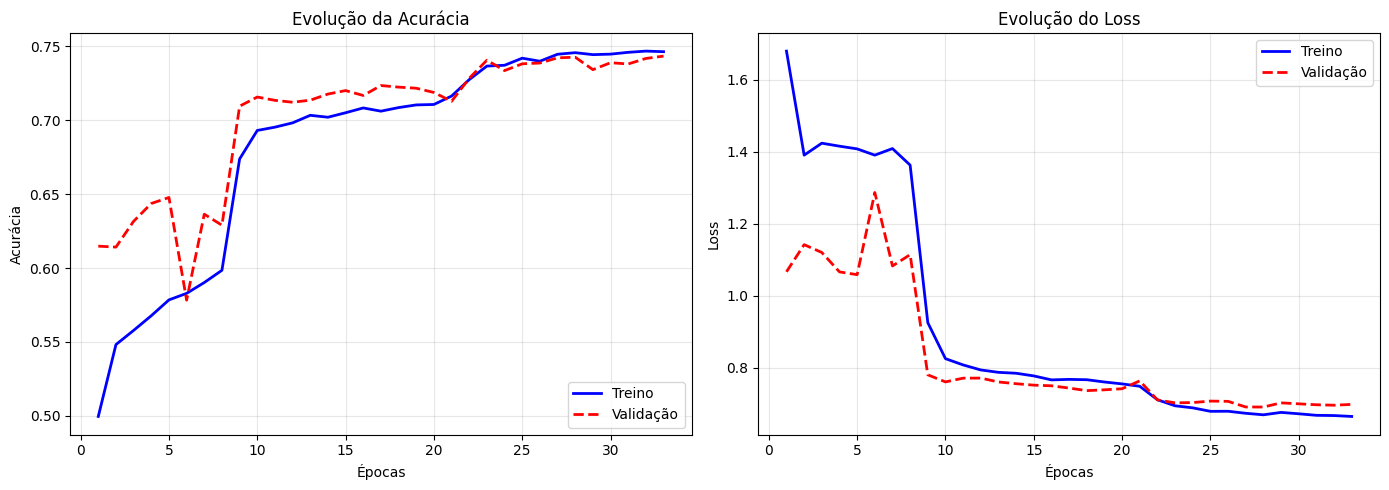

In [40]:

# ==========================================
# 8. AVALIAÇÃO DETALHADA (Multi-Classe)
# ==========================================
print("\nAvaliando modelo no conjunto de validação...")

y_pred_prob = model.predict(val_ds)
y_pred_prob = y_pred_prob[:len(y_val)]
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_val[:len(y_pred)].astype(int)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# AUC macro One-vs-Rest
auc_score = roc_auc_score(
    y_true, y_pred_prob,
    multi_class='ovr', average='macro'
)

kappa = cohen_kappa_score(y_true, y_pred)

# False Alarm Rate por classe
false_alarm_rates = []
for cls_idx in range(NUM_CLASSES):
    tn  = int(np.sum((y_pred != cls_idx) & (y_true != cls_idx)))
    fp  = int(np.sum((y_pred == cls_idx) & (y_true != cls_idx)))
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    false_alarm_rates.append(far)

mean_far = float(np.mean(false_alarm_rates))

print(f"AUC (macro OvR):          {auc_score:.4f}")
print(f"Cohen's Kappa:            {kappa:.4f}")
print(f"False Alarm Rate (macro): {mean_far:.4f}")
print("\nFalse Alarm Rate por classe:")
for cls, far in zip(CLASS_NAMES, false_alarm_rates):
    print(f"  {cls:6s}: {far:.4f}")

# ==========================================
# 9. SALVAR E PLOTAR
# ==========================================
model.save('modelo_ham10000_xception_multiclass.h5')
print("\nModelo final salvo: modelo_ham10000_xception_multiclass.h5")

plot_historico(history)

## 4. Resultados e Discussão

O treinamento foi configurado para 50 épocas com técnicas de *Early Stopping* para evitar o *overfitting* e obteve uma acuracia de 74% e AUC 0.947. Tempo total de treinamento: 16 horas.

## 5. Conclusão

Desempenho geral pode ser considerado bom para um problema de 7 classes, a acurácia de 74% com AUC de 0.947 é um resultado expressivo. O AUC próximo de 1.0 indica que o modelo separa bem as classes no espaço de probabilidade, mesmo quando erra na classificação final. Do ponto de vista clínico, errar um mel é mais grave do que dar um falso alarme. Um recall de 0.58 no melanoma significa que 4 em cada 10 melanomas não são detectados. Para uma aplicação médica real, seria necessário ajustar o threshold dessa classe ou aplicar pesos de classe maiores no treinamento.

## Referências

[1] ALOTAIBI, A.; ALSAEED, D. **Skin Cancer Detection Using Transfer Learning and Deep Attention Mechanisms**. Diagnostics (Basel), v. 15, n. 1, p. 99, jan. 2025. Disponível em: [https://pmc.ncbi.nlm.nih.gov/articles/PMC11720014/](https://pmc.ncbi.nlm.nih.gov/articles/PMC11720014/). Acesso em: 28 mar. 2026.


